# 11 服务化与接口开发第一部分 — API Smoke

> 贯穿式 notebook：随阶段 0–4 增量追加 C*，不是收尾才补。

| 单元 | 阶段 | 内容 |
|------|------|------|
| **C0** | 0 | 环境、依赖自检、`bootstrap`、`config`、`import app` |
| **C0.5** | 0 | Ollama 探活 + 确认 10 模块可 import（不冷启全量库） |
| **C1** | 1 | `ResponseModel`、`/health`/`/ready`、校验失败 → **400 + code=1001** |
| **C2** | 2 | mock `RagService.answer` + `SessionStore` 增删查（可选 sample 真跑） |
| **C3** | 3 | `POST /api/v1/qa` 成功 / 1001 / 会话两轮 + qa 日志 |
| **C4** | 4 | `POST /api/v1/qa/stream` 伪 SSE：meta → token* → done / error |
| **C4.5** | 4.5 | **全量 Dataset + Ollama** HTTP 真跑；导出报告图/JSON（供阶段 5） |

**内核请选 `med-rag-verify`**（与 01–10 相同）。若报 `No module named 'fastapi'`，多半是装到了别的环境。

> **C4.5 警告**：冷启全量 Chroma/BM25 + 多步 LLM，单条常需**数分钟**；默认 `RUN_LIVE_FULL=False`，确认资源就绪后再改 `True`。

## C0 — 环境初始化与骨架自检

In [1]:
from __future__ import annotations

import importlib
import subprocess
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, *cwd.parents]
STAGE11 = None
for c in candidates:
    hit = c / "11 服务化与接口开发第一部分" if c.name != "11 服务化与接口开发第一部分" else c
    if (hit / "app" / "config.py").is_file():
        STAGE11 = hit
        break
assert STAGE11 is not None, f"cannot find stage 11 from cwd={cwd}"

print("kernel python:", sys.executable)

# 必须先给「当前内核」装依赖，再 import app.main（后者依赖 fastapi）
required = ["fastapi", "uvicorn", "pydantic", "httpx"]
missing = []
for name in required:
    try:
        importlib.import_module(name)
        print(f"OK  {name}")
    except ImportError:
        missing.append(name)
        print(f"MISS {name}")

if missing:
    req = STAGE11 / "requirements.txt"
    print("Installing into kernel env from", req)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req)])
    importlib.invalidate_caches()
    for name in missing:
        importlib.import_module(name)
        print(f"OK  {name} (after install)")
else:
    print("All stage-0 deps present")

if str(STAGE11) not in sys.path:
    sys.path.insert(0, str(STAGE11))

from app.bootstrap import bootstrap_paths

paths = bootstrap_paths(STAGE11)
print("repo root:", paths["root"])
print("stage11:", paths["stage11"])
print("sys.path[0]:", sys.path[0])

kernel python: c:\Users\10138\miniconda3\envs\med-rag-verify\python.exe
OK  fastapi
OK  uvicorn
OK  pydantic
OK  httpx
All stage-0 deps present
repo root: D:\谷歌
stage11: D:\谷歌\11 服务化与接口开发第一部分
sys.path[0]: D:\谷歌\11 服务化与接口开发第一部分


In [5]:
from app.config import DEFAULT_CONFIG
from app.main import app
import app as app_pkg

print("app version:", app_pkg.__version__)
print("retrieval_mode:", DEFAULT_CONFIG.retrieval_mode)
print("pipeline_backend:", DEFAULT_CONFIG.pipeline_backend)
print("host:port:", f"{DEFAULT_CONFIG.host}:{DEFAULT_CONFIG.port}")
print("log_dir:", DEFAULT_CONFIG.log_dir)
print("FastAPI title:", app.title)

assert DEFAULT_CONFIG.retrieval_mode == "sample"
assert DEFAULT_CONFIG.pipeline_backend == "constrained10"
print("C0 config OK")

app version: 0.0.1
retrieval_mode: sample
pipeline_backend: constrained10
host:port: 127.0.0.1:8000
log_dir: D:\谷歌\11 服务化与接口开发第一部分\outputs\logs
FastAPI title: Medical RAG API
C0 config OK


In [6]:
from fastapi.testclient import TestClient

client = TestClient(app)
r = client.get("/")
print(r.status_code, r.json())
assert r.status_code == 200
# 阶段 1 起根路径已包进 ResponseModel：stage 在 data 里
body = r.json()
assert body["code"] == 0
assert body["data"]["stage"] == "5-done"
assert "request_id" in body
print("C0 root endpoint OK")

2026-07-24 16:50:02 | INFO | med_rag_api.middleware | request method=GET path=/ status=200 request_id=a024dc0a-1848-4f3c-b191-7cc71af185ee elapsed_ms=0.8
200 {'code': 0, 'message': 'ok', 'data': {'service': 'medical-rag-api', 'version': '0.0.1', 'stage': '1-contract', 'retrieval_mode': 'sample', 'pipeline_backend': 'constrained10'}, 'request_id': 'a024dc0a-1848-4f3c-b191-7cc71af185ee', 'timestamp': '2026-07-24T08:50:02.071402Z'}
C0 root endpoint OK


## C0.5 — Ollama 探活 + 上游 10 import（不加载全量索引）

- Ollama 未启动时：`ok=False` 可接受，不影响阶段 0 收尾。
- **不要**在本单元调用 `from_mode("full")` / 冷启 610 万库。

In [7]:
from app.probe import probe_ollama, try_import_stage10
import json

ollama = probe_ollama()
print("Ollama probe:")
print(json.dumps(ollama, ensure_ascii=False, indent=2))

st10 = try_import_stage10()
print("Stage10 import:")
print(json.dumps(st10, ensure_ascii=False, indent=2))

assert st10["ok"] is True, st10
print("C0.5 stage10 import OK (Ollama optional)")

Ollama probe:
{
  "ok": true,
  "base_url": "http://127.0.0.1:11434",
  "model_configured": "deepseek-r1:7b",
  "model_present": true,
  "models_sample": [
    "deepseek-r1:7b"
  ]
}
Stage10 import:
{
  "ok": true,
  "class": "ConstrainedGenerationPipeline",
  "module": "constrained_pipeline"
}
C0.5 stage10 import OK (Ollama optional)


### 启动空壳 API（可选，在终端运行）

```powershell
conda activate med-rag-verify
cd "D:\谷歌\11 服务化与接口开发第一部分"
python scripts/run_api.py
# 浏览器打开 http://127.0.0.1:8000/  与 http://127.0.0.1:8000/docs
```

## C1 — 统一响应 / 健康检查 / 1001 错误信封

先确保已跑过上面的 C0（`STAGE11`、`bootstrap`、deps）。


In [8]:
from app.schemas.response import PageModel, error_response, success_response

ok = success_response({"hello": "world"}, request_id="demo-ok")
err = error_response(code=1001, message="parameter error", request_id="demo-err", data={"errors": []})
page = PageModel(items=[1, 2, 3], total=3, page=1, page_size=10)

print("success:", ok.model_dump())
print("error:", err.model_dump())
print("page:", page.model_dump())
assert ok.code == 0 and err.code == 1001
print("C1 ResponseModel OK")


success: {'code': 0, 'message': 'ok', 'data': {'hello': 'world'}, 'request_id': 'demo-ok', 'timestamp': '2026-07-24T08:50:02.142750Z'}
error: {'code': 1001, 'message': 'parameter error', 'data': {'errors': []}, 'request_id': 'demo-err', 'timestamp': '2026-07-24T08:50:02.142750Z'}
page: {'items': [1, 2, 3], 'total': 3, 'page': 1, 'page_size': 10}
C1 ResponseModel OK


In [9]:
import importlib
import sys

# Jupyter 常缓存阶段 0 的旧 app（没有 /health）→ 会出现 404 {'detail': 'Not Found'}
# 这里强制卸掉并重新加载，避免必须手动 Restart Kernel。
for key in list(sys.modules):
    if key == "app" or key.startswith("app."):
        del sys.modules[key]

from app.bootstrap import bootstrap_paths
bootstrap_paths(STAGE11)

from app.main import app
from fastapi.testclient import TestClient

print("routes:", sorted({getattr(r, "path", None) for r in app.routes if getattr(r, "path", None)}))
client = TestClient(app)

h = client.get("/health")
print("/health", h.status_code, h.json())
assert h.status_code == 200, f"expected 200, got {h.status_code}: {h.text} (若 404，请 Restart Kernel 后从 C0 重跑)"
assert h.json().get("code") == 0, h.json()
assert h.headers.get("X-Request-Id") == h.json()["request_id"]

r = client.get("/ready")
print("/ready", r.status_code, r.json())
assert r.status_code == 200
assert r.json()["data"]["pipeline_loaded"] is False  # stage 2 才会加载

# 故意触发校验失败：空 message → HTTP 400 + business code 1001（不是裸 422）
bad = client.post("/api/v1/echo", json={"message": ""})
print("/echo bad", bad.status_code, bad.json())
assert bad.status_code == 400
assert bad.json()["code"] == 1001
assert "errors" in (bad.json().get("data") or {})

good = client.post("/api/v1/echo", json={"message": "ping"})
print("/echo good", good.status_code, good.json())
assert good.status_code == 200 and good.json()["data"]["echo"] == "ping"

print("C1 health + 1001 envelope OK")


2026-07-24 16:50:02 | INFO | med_rag_api.main | app_created version=0.0.1 retrieval_mode=sample backend=constrained10


routes: ['/', '/docs', '/docs/oauth2-redirect', '/openapi.json', '/redoc']
2026-07-24 16:50:02 | INFO | med_rag_api.middleware | request method=GET path=/health status=200 request_id=291d1f5c-a828-4cf8-bbdc-b44ad826843f elapsed_ms=3.1
/health 200 {'code': 0, 'message': 'ok', 'data': {'status': 'ok', 'version': '0.0.1', 'retrieval_mode': 'sample', 'pipeline_backend': 'constrained10', 'ollama': None, 'ollama_detail': None}, 'request_id': '291d1f5c-a828-4cf8-bbdc-b44ad826843f', 'timestamp': '2026-07-24T08:50:02.168685Z'}
2026-07-24 16:50:02 | INFO | med_rag_api.middleware | request method=GET path=/ready status=200 request_id=cd5ed88b-5c58-4f77-bd6a-47118415faee elapsed_ms=1.6
/ready 200 {'code': 0, 'message': 'ok', 'data': {'ready': False, 'pipeline_loaded': False, 'pipeline_mode': None, 'pipeline_backend': 'constrained10', 'last_error': None}, 'request_id': 'cd5ed88b-5c58-4f77-bd6a-47118415faee', 'timestamp': '2026-07-24T08:50:02.176184Z'}
2026-07-24 16:50:02 | INFO | med_rag_api.app.co

## C2 — RAG 服务封装 + 会话存储（mock，不冷启全量）

需已跑 C0（有 `STAGE11`）。本单元**默认用假 pipeline**，不调 Ollama、不加载 610 万库。


In [10]:
import importlib
import sys

for key in list(sys.modules):
    if key == "app" or key.startswith("app."):
        del sys.modules[key]

from app.bootstrap import bootstrap_paths
bootstrap_paths(STAGE11)

from app.config import Stage11Config
from app.services.rag_service import RagService
from app.services.session_store import MemorySessionStore, SessionTurn, format_session_prefix
from app.state import RUNTIME

# --- SessionStore ---
store = MemorySessionStore(Stage11Config(session_ttl_seconds=3600, session_max_turns=3))
s = store.create()
store.append(s.session_id, SessionTurn(query="What is MI?", answer="Myocardial infarction."))
store.append(s.session_id, SessionTurn(query="Treatment?", answer="Reperfusion therapy."))
got = store.require(s.session_id)
print("session_id:", got.session_id)
print("turns:", len(got.turns), [t.query for t in got.turns])
print("prefix sample:\n", format_session_prefix(got.turns))

# --- RagService with mock pipeline ---
class FakePipe:
    def __init__(self):
        self.retrieval_pipeline = type("R", (), {"top_k_final": 10})()
        self.calls = []
    def run(self, query, **kw):
        self.calls.append(query)
        return {
            "answer": "Mock answer based on context.",
            "sources": [{"index": 1, "chunk_id": "c1"}, {"index": 2, "chunk_id": "c2"}],
            "constraint_checks": {"boundary_hit": False, "citation": {"ok": True}},
            "generation_metrics": {"total_time_seconds": 0.01},
        }

pipe = FakePipe()
svc = RagService(pipeline=pipe, inject_history=True)
out = svc.answer(
    "follow-up question",
    top_k=5,
    session_history=got.turns,
)
print("answer:", out["answer"])
print("sources:", out["sources"])
print("top_k_mode:", out["top_k_mode"], "applied:", out["top_k_applied"])
print("effective_query preview:\n", out["effective_query"][:300], "...")
print("RUNTIME.pipeline_loaded:", RUNTIME.pipeline_loaded)
assert RUNTIME.pipeline_loaded is True
assert "Conversation context" in pipe.calls[0]
assert out["query"] == "follow-up question"
print("C2 mock RagService + SessionStore OK")


session_id: 12690b10-ab94-4f77-906f-be4e98758858
turns: 2 ['What is MI?', 'Treatment?']
prefix sample:
 [Conversation context]
Previous Q1: What is MI?
Previous A1: Myocardial infarction.
Previous Q2: Treatment?
Previous A2: Reperfusion therapy.

[Current question]

answer: Mock answer based on context.
sources: [{'index': 1, 'chunk_id': 'c1'}, {'index': 2, 'chunk_id': 'c2'}]
top_k_mode: retrieval.top_k_final applied: 5
effective_query preview:
 [Conversation context]
Previous Q1: What is MI?
Previous A1: Myocardial infarction.
Previous Q2: Treatment?
Previous A2: Reperfusion therapy.

[Current question]
follow-up question ...
RUNTIME.pipeline_loaded: True
C2 mock RagService + SessionStore OK


### （可选）sample 真跑 1 条

下面默认 `RUN_LIVE_SAMPLE = False`。若本机有样本库 + Ollama，可改为 `True`（可能较慢，仍避免 `full`）。


In [ ]:
RUN_LIVE_SAMPLE = False  # 改 True 才真跑；跑完可改回 False 避免误触

if not RUN_LIVE_SAMPLE:
    print("skip live sample (set RUN_LIVE_SAMPLE=True to enable)")
else:
    import time
    from app.config import Stage11Config
    from app.services.rag_service import RagService

    live_cfg = Stage11Config(retrieval_mode="sample", pipeline_backend="constrained10")
    live_svc = RagService(live_cfg)
    _t0 = time.perf_counter()
    live_out = live_svc.answer("metformin cardiovascular effects", top_k=5)
    live_wall_sec = time.perf_counter() - _t0
    print(f"live wall_clock: {live_wall_sec:.1f}s")
    print("live answer preview:", (live_out.get("answer") or "")[:400])
    print("sources:", len(live_out.get("sources") or []))
    print("constraint_checks keys:", list((live_out.get("constraint_checks") or {}).keys()))
    gm = live_out.get("generation_metrics") or {}
    if gm:
        print("generation_metrics.total_time_seconds:", gm.get("total_time_seconds"))
        print("generation_metrics.stage_times:", gm.get("stage_times"))


2026-07-24 16:51:18 | INFO | med_rag_api.rag_service | pipeline_loaded backend=constrained10 mode=sample
[Reranker] 加载 BAAI/bge-reranker-base（首次运行需下载 ~1.1GB，请耐心等待）...
[Reranker] 就绪，device=cuda
live answer preview: **Core Answer:**  
Based on the provided literature, there is no direct evidence regarding the cardiovascular effects of metformin. 

**Evidence Summary:**  
- **Chunk [1]:** The context discusses NVP-containing antiretroviral therapy's impact on HDL-c and TC:HLD-c ratio but does not relate to metformin.

**Uncertainty Statement:**  
There is insufficient evidence in the provided context to determ
sources: 5
constraint_checks keys: ['citation', 'format', 'boundary_hit']


### C2 live sample 运行记录与分析（2026-07-24）

> 对应上一格：`retrieval_mode=sample` · `pipeline_backend=constrained10` · query=`metformin cardiovascular effects` · `top_k=5`  
> **墙钟耗时（人工计时）≈ 1 分 45 秒（约 105 s）**

#### 现象摘要

| 项 | 观测 |
|----|------|
| 模式 | sample（样本库 ~1,267 chunks，非全量 610 万） |
| 加载日志 | 出现 `[Reranker] 加载 BAAI/bge-reranker-base` → `device=cuda`（首跑/冷启会含模型就绪成本） |
| 返回 | `sources=5`（与 top_k=5 一致）；`constraint_checks` 含 `citation` / `format` / `boundary_hit` |
| 答案倾向 | 文献上下文**不足以**说明 metformin 心血管效应 → 偏「证据不足 / 无法从所给文献判定」（样本库常见，不一定是 bug） |

#### 耗时怎么理解（为何会到 ~1–2 分钟）

1. **冷启一次性成本**：`RagService` 懒加载整条 10 约束流水线 + 检索组件；日志里明确有 **cross-encoder reranker** 加载（CUDA）。同一进程里再问第二问通常会短一截（不再重复整库加载，但仍有检索+多步 LLM）。  
2. **同步生成链路**：10 约束管线 = 检索 → 组装 →（可能多步）Ollama 生成 → CitationGuard / FormatChecker（可能重试）。sample 虽小，**LLM 多步仍是大头**。  
3. **对阶段 3 API 的启示**：`POST /qa` 的客户端超时不宜按「几秒」估；开发机 sample 冷启按 **2 分钟量级**留余量；全量 `full` 往往更慢，需 `/ready` 预热 + 单例常驻。

#### 质量侧一句话

本次答案「说没有直接证据」在 **sample 语料**上可接受：样本库不是为 metformin RCT 覆盖而选的。要验「答得对不对」应看 09/10 全量或已知命中文献的 query；阶段 11 C2 真跑目标是 **服务封装能打通 live**，不是医学质量终审。

#### 复现

上一格保持 `RUN_LIVE_SAMPLE = True`，Kernel 已加载过 pipeline 时再跑一次，对比墙钟是否明显下降（验证「冷启 vs 热路径」）。


In [13]:
# 从上一格 live_out 抽取可机器核对的字段（若刚跑过 live；否则跳过）
import json

WALL_CLOCK_SEC = float(globals().get("live_wall_sec") or 105)  # 优先自动计时；否则用本次人工 ≈1分45秒

if "live_out" not in globals() or not isinstance(live_out, dict):
    print("no live_out in memory — 先跑上一格 RUN_LIVE_SAMPLE=True")
else:
    metrics = live_out.get("generation_metrics") or {}
    checks = live_out.get("constraint_checks") or {}
    sources = live_out.get("sources") or []
    record = {
        "date": "2026-07-24",
        "query": live_out.get("query") or "metformin cardiovascular effects",
        "retrieval_mode": "sample",
        "pipeline_backend": "constrained10",
        "top_k_applied": live_out.get("top_k_applied"),
        "top_k_mode": live_out.get("top_k_mode"),
        "wall_clock_sec": WALL_CLOCK_SEC,
        "pipeline_total_time_seconds": metrics.get("total_time_seconds"),
        "stage_times": metrics.get("stage_times"),
        "n_sources": len(sources),
        "source_ids": [s.get("chunk_id") or s.get("doc_id") or s.get("index") for s in sources[:5]],
        "constraint_boundary_hit": checks.get("boundary_hit"),
        "citation_ok": (checks.get("citation") or {}).get("ok"),
        "format_ok": (checks.get("format") or {}).get("ok"),
        "retry_count": live_out.get("retry_count"),
        "repaired": live_out.get("repaired"),
        "answer_preview": (live_out.get("answer") or "")[:240],
        "note": "sample 库证据不足时弱证据/无法判定属预期；墙钟含冷启 reranker+多步 LLM；人工首跑≈105s",
    }
    print(json.dumps(record, ensure_ascii=False, indent=2))

    # 粗对比：若 metrics 有 total_time，看墙钟与流水线计时的差距（加载/其它开销）
    pt = metrics.get("total_time_seconds")
    if isinstance(pt, (int, float)) and pt > 0:
        overhead = WALL_CLOCK_SEC - pt
        print(f"\nwall_clock={WALL_CLOCK_SEC:.1f}s vs generation_metrics.total={pt:.1f}s → approx_overhead={overhead:.1f}s (含懒加载/reranker 等)")


{
  "date": "2026-07-24",
  "query": "metformin cardiovascular effects",
  "retrieval_mode": "sample",
  "pipeline_backend": "constrained10",
  "top_k_applied": 5,
  "top_k_mode": "retrieval.top_k_final",
  "wall_clock_sec": 105.0,
  "pipeline_total_time_seconds": 62.162,
  "stage_times": {
    "assemble": 14.756,
    "evidence_eval": 0.0,
    "draft": 39.825,
    "review": 0.0,
    "final": 7.581,
    "postprocess": 0.0
  },
  "n_sources": 5,
  "source_ids": [
    "PMC523838_chunk4",
    "PMC520826",
    "PMC521687",
    "PMC523844",
    "PMC523836"
  ],
  "constraint_boundary_hit": false,
  "citation_ok": true,
  "format_ok": true,
  "retry_count": 0,
  "repaired": false,
  "answer_preview": "**Core Answer:**  \nBased on the provided literature, there is no direct evidence regarding the cardiovascular effects of metformin. \n\n**Evidence Summary:**  \n- **Chunk [1]:** The context discusses NVP-containing antiretroviral therapy's imp",
  "note": "sample 库证据不足时弱证据/无法判定属预期；墙钟含冷启 reranke

## C3 — 同步问答接口 `POST /api/v1/qa`（mock pipeline）

需已跑 C0（有 `STAGE11`）。本单元用 `dependency_overrides` 注入假 `RagService`，**不**调 Ollama。


In [2]:
import importlib
import json
import sys
from pathlib import Path

for key in list(sys.modules):
    if key == "app" or key.startswith("app."):
        del sys.modules[key]

from app.bootstrap import bootstrap_paths
bootstrap_paths(STAGE11)

from fastapi.testclient import TestClient
from app.config import Stage11Config
from app.deps import get_qa_logger, get_rag_service, get_session_store, reset_singletons
from app.main import app
from app.services.qa_logger import QACallLogger
from app.services.rag_service import RagService
from app.services.session_store import MemorySessionStore

reset_singletons()

class FakePipe:
    def __init__(self):
        self.retrieval_pipeline = type("R", (), {"top_k_final": 10})()
        self.calls = []
    def run(self, query, **kw):
        self.calls.append(query)
        return {
            "answer": f"mock:{query[-30:]}",
            "sources": [{"index": 1, "chunk_id": "c1"}],
            "constraint_checks": {"boundary_hit": False, "citation": {"ok": True}},
            "generation_metrics": {"total_time_seconds": 0.01},
            "retry_count": 0,
            "repaired": False,
        }

cfg = Stage11Config()
store = MemorySessionStore(cfg)
pipe = FakePipe()
rag = RagService(cfg, pipeline=pipe, inject_history=True)
qlog = QACallLogger(cfg)
# 本 notebook 演示写入独立文件，避免污染正式 qa_calls.jsonl
qlog.path = STAGE11 / "outputs" / "logs" / "qa_calls_c3_demo.jsonl"
if qlog.path.exists():
    qlog.path.unlink()

app.dependency_overrides[get_rag_service] = lambda: rag
app.dependency_overrides[get_session_store] = lambda: store
app.dependency_overrides[get_qa_logger] = lambda: qlog
client = TestClient(app)

# 1) 合法问答
ok = client.post("/api/v1/qa", json={"query": "metformin effects", "top_k": 5})
print("OK", ok.status_code, ok.json())
assert ok.status_code == 200 and ok.json()["code"] == 0
sid = ok.json()["data"]["session_id"]
assert ok.json()["data"]["sources"]

# 2) 空 query → 1001
bad1 = client.post("/api/v1/qa", json={"query": ""})
print("empty", bad1.status_code, bad1.json())
assert bad1.status_code == 400 and bad1.json()["code"] == 1001

# 3) 非法 top_k → 1001
bad2 = client.post("/api/v1/qa", json={"query": "x", "top_k": 999})
print("top_k", bad2.status_code, bad2.json())
assert bad2.status_code == 400 and bad2.json()["code"] == 1001

# 4) 同 session 第二轮
ok2 = client.post("/api/v1/qa", json={"query": "follow up", "session_id": sid, "top_k": 3})
print("turn2", ok2.status_code, ok2.json()["data"]["session_id"])
assert ok2.json()["data"]["session_id"] == sid
assert len(store.require(sid).turns) == 2
assert "Conversation context" in pipe.calls[1]

# 5) 调用日志
lines = qlog.path.read_text(encoding="utf-8").strip().splitlines()
print("log lines:", len(lines))
print("last log:", json.loads(lines[-1]))
assert any(json.loads(x)["status"] == "ok" for x in lines)

# 清理 override，避免影响后续 cell
app.dependency_overrides.clear()
reset_singletons()
print("C3 sync /api/v1/qa OK")


2026-07-25 07:10:49 | INFO | med_rag_api.main | app_created version=0.0.1 retrieval_mode=sample backend=constrained10
2026-07-25 07:10:49 | INFO | med_rag_api.qa_logger | qa_call status=ok code=0 request_id=4edd862f-2347-4635-9e2a-931a8e236f73 latency_ms=0.1
2026-07-25 07:10:49 | INFO | med_rag_api.middleware | request method=POST path=/api/v1/qa status=200 request_id=4edd862f-2347-4635-9e2a-931a8e236f73 elapsed_ms=7.9
OK 200 {'code': 0, 'message': 'ok', 'data': {'answer': 'mock:metformin effects', 'sources': [{'index': 1, 'chunk_id': 'c1'}], 'session_id': 'acf62a47-d6c8-44fe-9c1a-5f63860bdcde', 'generation_metrics': {'total_time_seconds': 0.01}, 'constraint_checks': {'boundary_hit': False, 'citation': {'ok': True}}, 'retry_count': 0, 'repaired': False, 'top_k_applied': 5, 'top_k_mode': 'retrieval.top_k_final'}, 'request_id': '4edd862f-2347-4635-9e2a-931a8e236f73', 'timestamp': '2026-07-24T23:10:49.221225Z'}
2026-07-25 07:10:49 | INFO | med_rag_api.app.core.exceptions | validation_erro

c:\Users\10138\miniconda3\envs\med-rag-verify\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


## C4 — 伪流式 SSE `POST /api/v1/qa/stream`（mock pipeline）

需已跑 C0。本单元同样用 `dependency_overrides`，**不**调 Ollama。

事件约定：`meta`（含 `stream_mode=pseudo`）→ `token*`（对完整 answer 分块）→ `done`；管道异常走 `error`（字段对齐同步错误信封）。**不是** Ollama token 级真流式。


In [3]:
import json
import sys
from pathlib import Path

for key in list(sys.modules):
    if key == "app" or key.startswith("app."):
        del sys.modules[key]

from app.bootstrap import bootstrap_paths
bootstrap_paths(STAGE11)

from fastapi.testclient import TestClient
from app.config import Stage11Config
from app.core.error_codes import ErrorCode
from app.core.exceptions import AppException
from app.deps import get_qa_logger, get_rag_service, get_session_store, reset_singletons
from app.main import app
from app.services.qa_logger import QACallLogger
from app.services.rag_service import RagService
from app.services.session_store import MemorySessionStore


def parse_sse(raw: str):
    events = []
    for block in [b for b in raw.split("\n\n") if b.strip()]:
        name, data_lines = "message", []
        for line in block.splitlines():
            if line.startswith("event:"):
                name = line[len("event:") :].strip()
            elif line.startswith("data:"):
                data_lines.append(line[len("data:") :].strip())
        events.append((name, json.loads("\n".join(data_lines)) if data_lines else {}))
    return events


class FakePipe:
    def __init__(self):
        self.retrieval_pipeline = type("R", (), {"top_k_final": 10})()
        self.fail = None
        self.answer = "First clause. Second clause ends here!"

    def run(self, query, **kw):
        if self.fail is not None:
            raise self.fail
        return {
            "answer": self.answer,
            "sources": [{"index": 1, "chunk_id": "c1"}],
            "constraint_checks": {"boundary_hit": False, "citation": {"ok": True}},
            "generation_metrics": {"total_time_seconds": 0.01},
            "retry_count": 0,
            "repaired": False,
        }


reset_singletons()
cfg = Stage11Config(stream_chunk_chars=10)
store = MemorySessionStore(cfg)
pipe = FakePipe()
rag = RagService(cfg, pipeline=pipe, inject_history=True)
qlog = QACallLogger(cfg)
qlog.path = STAGE11 / "outputs" / "logs" / "qa_calls_c4_demo.jsonl"
if qlog.path.exists():
    qlog.path.unlink()

app.dependency_overrides[get_rag_service] = lambda: rag
app.dependency_overrides[get_session_store] = lambda: store
app.dependency_overrides[get_qa_logger] = lambda: qlog
client = TestClient(app)

# 1) 成功：meta → token* → done
with client.stream("POST", "/api/v1/qa/stream", json={"query": "stream demo", "top_k": 3}) as resp:
    assert resp.status_code == 200
    assert resp.headers.get("X-Stream-Mode") == "pseudo"
    raw = "".join(resp.iter_text())

events = parse_sse(raw)
names = [n for n, _ in events]
print("event order:", names)
print("stream_mode (meta):", events[0][1].get("stream_mode"))
assert names[0] == "meta" and events[0][1]["stream_mode"] == "pseudo"
assert "token" in names and names[-1] == "done"
tokens = "".join(d["text"] for n, d in events if n == "token")
done = next(d for n, d in events if n == "done")
print("tokens joined:", repr(tokens))
print("done keys:", sorted(done.keys()))
assert tokens == done["answer"] == pipe.answer
assert done["sources"] and done["constraint_checks"]

# 2) 管道失败 → error 事件（HTTP 仍 200，错误在 SSE 体内）
pipe.fail = AppException(ErrorCode.MODEL_CALL_FAILED, detail="ollama down")
with client.stream("POST", "/api/v1/qa/stream", json={"query": "will fail"}) as resp:
    assert resp.status_code == 200
    raw_err = "".join(resp.iter_text())
err_events = parse_sse(raw_err)
err_names = [n for n, _ in err_events]
print("error path events:", err_names)
assert err_names[0] == "meta" and "error" in err_names and "done" not in err_names
err = next(d for n, d in err_events if n == "error")
print("error payload:", err)
assert err["code"] == int(ErrorCode.MODEL_CALL_FAILED)

# 3) 入参校验仍走 JSON 1001（流未开始）
bad = client.post("/api/v1/qa/stream", json={"query": ""})
print("empty query:", bad.status_code, bad.json()["code"])
assert bad.status_code == 400 and bad.json()["code"] == 1001

print("log file:", qlog.path)
print("C4 pseudo SSE OK — stream_mode=pseudo (not live Ollama tokens)")

app.dependency_overrides.clear()
reset_singletons()


2026-07-25 07:10:53 | INFO | med_rag_api.main | app_created version=0.0.1 retrieval_mode=sample backend=constrained10
2026-07-25 07:10:53 | INFO | med_rag_api.middleware | request method=POST path=/api/v1/qa/stream status=200 request_id=0e8875fc-2676-4da7-80ee-f06487d6b41a elapsed_ms=6.7
2026-07-25 07:10:53 | INFO | med_rag_api.qa_logger | qa_call status=ok code=0 request_id=0e8875fc-2676-4da7-80ee-f06487d6b41a latency_ms=1.7
event order: ['meta', 'token', 'token', 'token', 'token', 'token', 'done']
stream_mode (meta): pseudo
tokens joined: 'First clause. Second clause ends here!'
done keys: ['answer', 'constraint_checks', 'generation_metrics', 'repaired', 'retry_count', 'session_id', 'sources', 'stream_mode', 'top_k_applied', 'top_k_mode']
2026-07-25 07:10:53 | INFO | med_rag_api.middleware | request method=POST path=/api/v1/qa/stream status=200 request_id=645dbaac-aede-4169-953d-af20f3570fae elapsed_ms=1.4
2026-07-25 07:10:53 | INFO | med_rag_api.qa_logger | qa_call status=error code

## C4.5 — 全量环境真跑（阶段 4.5 · 供阶段 5 报告）

目标：最大程度贴近未来使用路径 —— **`retrieval_mode=full`** + **Ollama** + 真实 `RagService`（**无 mock**）。

| 步骤 | 内容 |
|------|------|
| 1 | Dataset / BM25 manifest / Ollama 就绪自检 |
| 2 | 主线程预热 `ensure_pipeline()` |
| 3 | 主线程 `rag.answer` 实跑 1 条（权威证据） |
| 4 | （默认）同 session 第二轮 + 伪 SSE 事件重建 |
| 5 | （可选）热身后 `TestClient` HTTP 探针 |
| 6 | 导出 `outputs/reports/full_api_smoke*.json/png` |

> **Windows 说明**：中文路径/云同步盘下，Starlette 同步路由线程池可能对 `transformers` 报 `WinError 6714`。阶段 4.5 **以主线程全量跑通为准**；HTTP 探针成功则加分。

也可 CLI：`python scripts/run_full_api_smoke.py`（需在阶段 11 目录、`med-rag-verify`）。


In [4]:
# C4.5-A：全量资源自检（不加载 610 万 pipeline）
import json
import sys

for key in list(sys.modules):
    if key == "app" or key.startswith("app."):
        del sys.modules[key]

from app.bootstrap import bootstrap_paths
bootstrap_paths(STAGE11)

from app.probe import probe_full_dataset, probe_ollama

ready = probe_full_dataset(check_chroma_collection=False)
print(json.dumps(ready, ensure_ascii=False, indent=2))
print("\nollama detail:", probe_ollama())
assert ready["chroma_full_exists"], "missing chroma_db_full"
assert ready["bm25_manifest_ok"], "bm25_full manifest not completed"
print("\nREADY for full live?" , ready["ready"])
if not ready["ready"]:
    print("→ 先启动 Ollama 并确认模型 deepseek-r1:7b；Dataset 路径见上。")


{
  "ready": true,
  "dataset_root": "D:\\谷歌\\Dataset",
  "chroma_full_dir": "D:\\谷歌\\Dataset\\chroma\\chroma_db_full",
  "chroma_full_exists": true,
  "collection_expected": "pmc_oa_comm_full",
  "collection_ok": null,
  "collection_detail": null,
  "bm25_full_dir": "D:\\谷歌\\Dataset\\bm25\\bm25_full",
  "bm25_manifest_ok": true,
  "bm25_num_shards": 62,
  "bm25_total_chunks": 6107296,
  "bm25_status": "completed",
  "chunks_jsonl_exists": true,
  "chunks_jsonl": "D:\\谷歌\\Dataset\\processed\\oa_comm_chunks.jsonl",
  "slim_jsonl_exists": true,
  "ollama": {
    "ok": true,
    "base_url": "http://127.0.0.1:11434",
    "model_configured": "deepseek-r1:7b",
    "model_present": true,
    "models_sample": [
      "deepseek-r1:7b"
    ]
  },
  "hints": [
    "Set RUN_LIVE_FULL=True only after ready=True",
    "Expect multi-minute cold start (Chroma+BM25+reranker+Ollama)",
    "Keep a single RagService singleton — do not from_mode(full) per request"
  ]
}

ollama detail: {'ok': True, 'base_u

In [6]:
# C4.5-B：全量 HTTP 真跑（默认关闭；改 True 后执行，可能数分钟～十余分钟）
RUN_LIVE_FULL = True  # ← 改 True 才跑；跑完可改回 False
RUN_STREAM = True
QUERY = "metformin cardiovascular effects"
TOP_K = 5

if not RUN_LIVE_FULL:
    print("skip full live (set RUN_LIVE_FULL=True to enable)")
    print("tip: or run `python scripts/run_full_api_smoke.py` in a terminal")
else:
    from app.full_smoke import run_full_http_smoke
    from app.probe import probe_full_dataset

    gate = probe_full_dataset()
    if not gate.get("ready"):
        raise RuntimeError(f"environment not ready: {gate}")

    full_record = run_full_http_smoke(
        query=QUERY,
        top_k=TOP_K,
        run_stream=RUN_STREAM,
        http_timeout=900.0,
    )
    print("ok:", full_record.get("ok"))
    print("warmup_sec:", full_record.get("warmup_sec"))
    print("error:", full_record.get("error"))
    if full_record.get("sync"):
        s = full_record["sync"]
        print(
            f"sync wall={s.get('wall_clock_sec')}s "
            f"pipeline={s.get('pipeline_total_time_seconds')}s "
            f"n_sources={s.get('n_sources')} "
            f"citation_ok={s.get('citation_ok')} format_ok={s.get('format_ok')}"
        )
        print("answer_preview:\n", (s.get("answer_preview") or "")[:500])
    if full_record.get("stream"):
        st = full_record["stream"]
        print(
            "stream events:", st.get("event_names"),
            "wall=", st.get("wall_clock_sec"),
            "n_token=", st.get("n_token_events"),
        )
    print("artifacts:", full_record.get("artifacts"))


2026-07-25 07:37:23 | INFO | med_rag_api.rag_service | pipeline_loaded backend=constrained10 mode=full
2026-07-25 07:37:23 | INFO | med_rag_api.full_smoke | full_pipeline_warmup_sec=1.9
[Reranker] 加载 BAAI/bge-reranker-base（首次运行需下载 ~1.1GB，请耐心等待）...
[Reranker] 就绪，device=cuda
2026-07-25 07:40:23 | INFO | med_rag_api.qa_logger | qa_call status=ok code=0 request_id=a373358a-493f-41f8-b92c-2aa6930b6f26 latency_ms=179528.7
2026-07-25 07:43:57 | INFO | med_rag_api.qa_logger | qa_call status=ok code=0 request_id=95e14a9f-0cea-4c5a-8803-0539ad8f60a3 latency_ms=214488.6
2026-07-25 07:43:57 | INFO | med_rag_api.main | app_created version=0.0.1 retrieval_mode=sample backend=constrained10
2026-07-25 07:43:57 | INFO | med_rag_api.middleware | request method=GET path=/ready status=200 request_id=00c7c9a8-7fc3-46ef-b840-d4481d4d24ab elapsed_ms=3.5
2026-07-25 07:46:04 | INFO | med_rag_api.qa_logger | qa_call status=ok code=0 request_id=807a206d-b92f-4674-afa4-5243de42f8db latency_ms=126231.3
2026-07-25 

using in-memory full_record


### 全量 live 摘要（阶段 4.5）

| 项 | 值 |
|----|-----|
| ok | `True` |
| query | `metformin cardiovascular effects` |
| retrieval_mode | `full` |
| warmup_sec | `1.89` |
| sync wall / pipeline | `179.53` s / `179.526` s |
| n_sources | `5` |
| citation / format / boundary | `True` / `True` / `False` |
| session_turns | `2` |
| stream n_token | `118` |


answer_preview:
 **Core Answer:**

Metformin exhibits various cardiovascular effects depending on its application context:

1. **In Heart Failure (HF):** Metformin is beneficial for HF patients with type 2 diabetes mellitus (T2DM), reducing HF incidence and mortality through mechanisms such as improving energy metabolism, reducing fibrosis, limiting advanced glycation end-products (AGEs), and inhibiting apoptosis.


**full_api_smoke_overview.png**

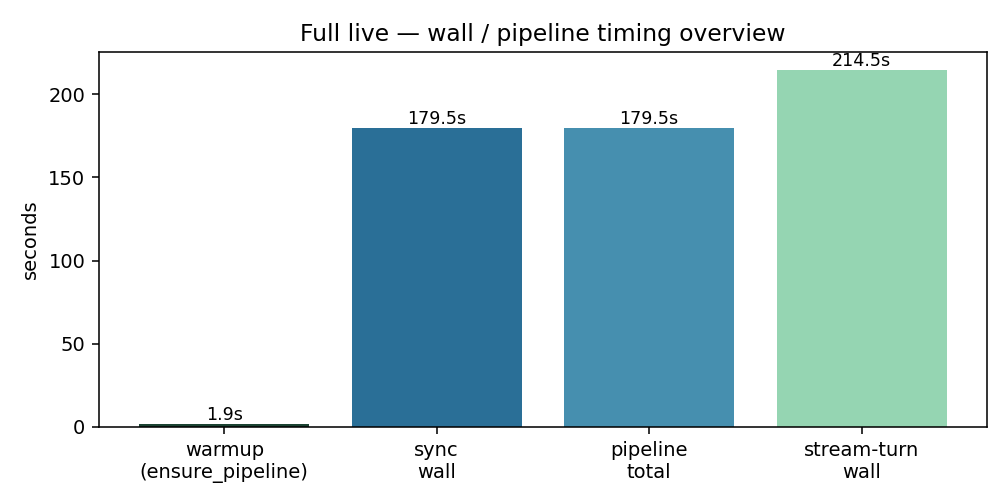

**full_api_smoke_stage_times.png**

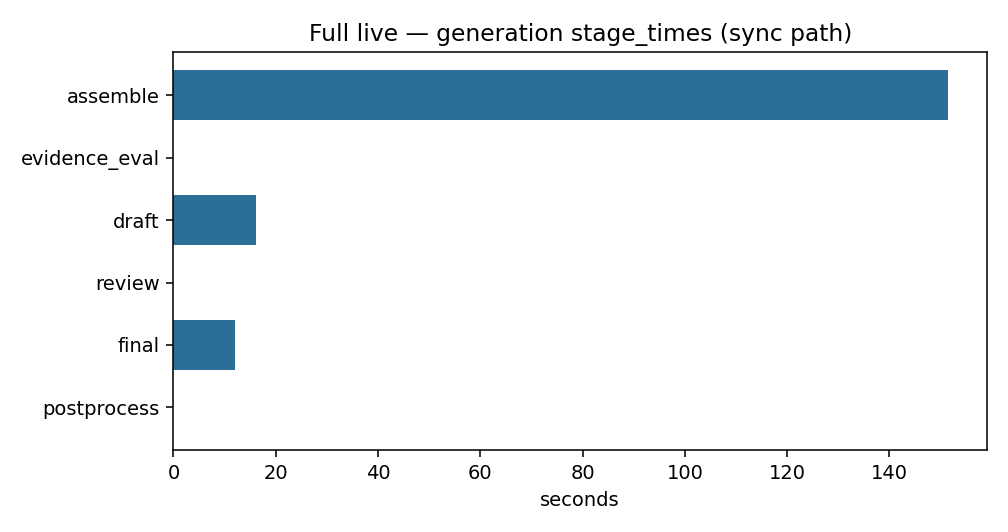

**full_api_smoke_constraints.png**

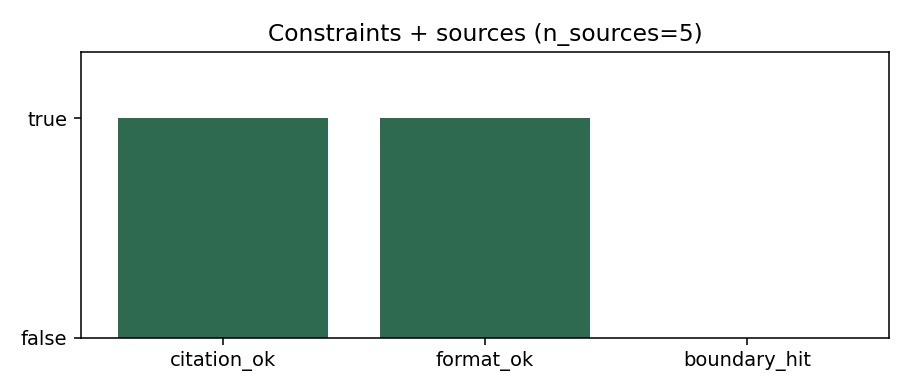

**full_api_smoke_sse_timeline.png**

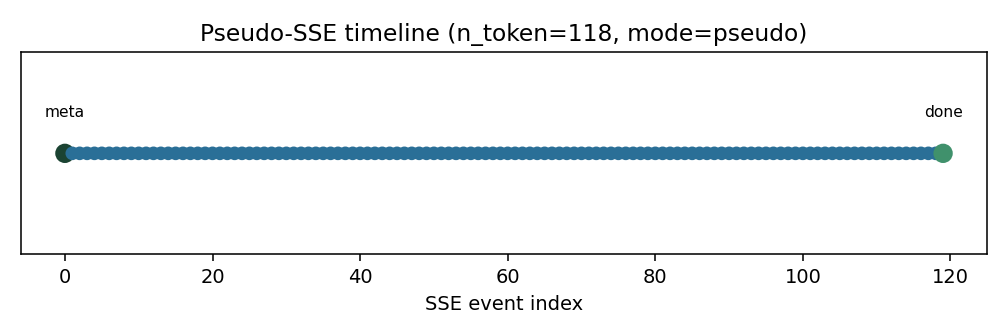

In [7]:
# C4.5-C：可视化展示（优先用刚跑的 full_record；否则读已落盘 JSON / PNG）
from pathlib import Path
from IPython.display import Image, display, Markdown
import json

report_dir = STAGE11 / "outputs" / "reports"
json_path = report_dir / "full_api_smoke.json"

rec = globals().get("full_record")
if not isinstance(rec, dict) and json_path.is_file():
    rec = json.loads(json_path.read_text(encoding="utf-8"))
    print("loaded from disk:", json_path)
elif isinstance(rec, dict):
    print("using in-memory full_record")
else:
    rec = None
    print("no full_record yet — 先跑 C4.5-B 或 scripts/run_full_api_smoke.py")

if rec:
    sync = rec.get("sync") or {}
    display(Markdown(
        f"""### 全量 live 摘要（阶段 4.5）

| 项 | 值 |
|----|-----|
| ok | `{rec.get("ok")}` |
| query | `{rec.get("query")}` |
| retrieval_mode | `{rec.get("retrieval_mode")}` |
| warmup_sec | `{rec.get("warmup_sec")}` |
| sync wall / pipeline | `{sync.get("wall_clock_sec")}` s / `{sync.get("pipeline_total_time_seconds")}` s |
| n_sources | `{sync.get("n_sources")}` |
| citation / format / boundary | `{sync.get("citation_ok")}` / `{sync.get("format_ok")}` / `{sync.get("constraint_boundary_hit")}` |
| session_turns | `{rec.get("session_turns")}` |
| stream n_token | `{(rec.get("stream") or {}).get("n_token_events")}` |
"""
    ))
    print("answer_preview:\n", (sync.get("answer_preview") or "")[:600])

# 展示报告图（若尚未生成且有 record，可再 render）
arts = (rec or {}).get("artifacts") or {}
png_keys = ["overview_png", "stage_times_png", "constraints_png", "sse_timeline_png"]
missing = [k for k in png_keys if not arts.get(k) or not Path(arts[k]).is_file()]
if rec and rec.get("ok") and missing:
    from app.full_smoke import render_report_figures
    arts.update(render_report_figures(rec, report_dir))
    print("re-rendered:", missing)

for key in png_keys:
    p = arts.get(key) or str(report_dir / f"full_api_smoke_{key.replace('_png','')}.png")
    # normalize names for fallback
    fallback = {
        "overview_png": report_dir / "full_api_smoke_overview.png",
        "stage_times_png": report_dir / "full_api_smoke_stage_times.png",
        "constraints_png": report_dir / "full_api_smoke_constraints.png",
        "sse_timeline_png": report_dir / "full_api_smoke_sse_timeline.png",
    }[key]
    path = Path(arts.get(key) or fallback)
    if path.is_file():
        display(Markdown(f"**{path.name}**"))
        display(Image(filename=str(path)))
    else:
        print("missing figure:", path)


### C4.5 运行记录（最新 · 已落盘 · 供阶段 5 报告）

> CLI：`python scripts/run_full_api_smoke.py` · `retrieval_mode=full` · Ollama `deepseek-r1:7b` · query=`metformin cardiovascular effects`  
> 原始 JSON：`outputs/reports/full_api_smoke.json` · 正式报告：`docs/服务化接口报告.md`

| 项 | 最新结果 |
|----|----------|
| 资源自检 | chroma_db_full + bm25_full(62 shards / 6.1M) + Ollama ✅ |
| 主路径 | 主线程 `RagService.answer`（权威） |
| sync 墙钟 | **179.53 s**（assemble≈151.5 s；draft≈16.1 s；final≈12.0 s） |
| 第二轮（伪流式素材） | **214.49 s**；`n_token_events=118`；`session_turns=2` |
| 约束 | citation_ok / format_ok = true；boundary_hit=false |
| sources（sync） | PMC6213955, PMC10932445, PMC9441545, PMC8951049, PMC9464374…（全量 PMC） |
| HTTP 探针（热身后） | `/ready` 200 · `POST /qa` **200 / code=0**（≈126 s，top_k=3） |
| 调用日志 | `qa_calls_full_smoke.jsonl` 含 request_id / latency_ms / status=ok |
| 产物 | `outputs/reports/full_api_smoke*.json/png` + JSONL |

跑 **C4.5-C** 可从磁盘加载图与摘要。正式文字说明见阶段 5 报告。
